<a href="https://colab.research.google.com/github/Arup3201/reint/blob/main/recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import json
import requests
from datetime import datetime
from collections import defaultdict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def load_dataset(output_file: str = "dataset.json") -> None:
    wind_api = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom=2024-01-01&settlementDateTo=2024-01-31&fuelType=WIND"
    forecast_api = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom=2024-01-01&publishDateTimeTo=2024-01-31"

    # Fetch actual wind data
    res = requests.get(wind_api)
    res.raise_for_status()
    actual_wind_data = res.json()

    # Fetch forecasted wind data
    res = requests.get(forecast_api)
    res.raise_for_status()
    forecasted_wind_data = res.json()

    # Build a lookup map from startTime -> list of forecast entries
    forecast_map = defaultdict(list)
    for entry in forecasted_wind_data:
        forecast_map[entry["startTime"]].append(entry)

    dataset = []
    for actual in actual_wind_data:
        start_time = actual["startTime"]
        forecasts = forecast_map.get(start_time)

        if forecasts:
            # One row per forecast matched to this actual startTime
            for forecast in forecasts:
                dataset.append({
                    "targetTime":  start_time,
                    "publishTime": forecast["publishTime"],
                    "actual":      actual["generation"],
                    "forecast":    forecast["generation"],
                })
        else:
            dataset.append({
                "targetTime":  start_time,
                "publishTime": None,
                "actual":      actual["generation"],
                "forecast":    None,
            })

    # Sort by targetTime ascending
    dataset.sort(key=lambda x: datetime.fromisoformat(x["targetTime"]))

    # Persist to JSON file instead of a global variable
    with open(output_file, "w") as f:
        json.dump(dataset, f, indent=2)

In [3]:
load_dataset()

In [4]:
def read_dataset(input_file: str = "dataset.json") -> pd.DataFrame:
    df = pd.read_json(input_file)
    df["targetTime"] = pd.to_datetime(df["targetTime"])
    df["publishTime"] = pd.to_datetime(df["publishTime"])
    return df

In [5]:
dataset = read_dataset()

In [6]:
dataset.head()

,targetTime,publishTime,actual,forecast
0,2024-01-01 00:00:00+00:00,NaT,10402,NaN
1,2024-01-01 00:30:00+00:00,NaT,10845,NaN
2,2024-01-01 01:00:00+00:00,NaT,11218,NaN
3,2024-01-01 01:30:00+00:00,NaT,11223,NaN
4,2024-01-01 02:00:00+00:00,NaT,11234,NaN


In [7]:
df = dataset[dataset["forecast"].notna()]

In [8]:
df.head()

,targetTime,publishTime,actual,forecast
42,2024-01-01 21:00:00+00:00,2024-01-01 22:30:00+00:00,13953,11736.0
43,2024-01-01 21:00:00+00:00,2024-01-01 18:30:00+00:00,13953,11730.0
44,2024-01-01 21:00:00+00:00,2024-01-01 15:30:00+00:00,13953,10634.0
45,2024-01-01 21:00:00+00:00,2024-01-01 11:30:00+00:00,13953,10072.0
46,2024-01-01 21:00:00+00:00,2024-01-01 09:30:00+00:00,13953,10065.0


In [9]:
median = df["actual"].median()
print(f"Median={median:.2f}")

Median=9602.00


In [10]:
mean = df["actual"].mean()
print(f"Mean={mean:.2f}")

Mean=9793.64


**The average and median values for the wind generation is in the range 9000-10000 MW.**

> Disclaimer: Wind sometimes drops very low and due to that grid operators can't rely on mean or median values.

Let's first look at the distribution of wind generation values.

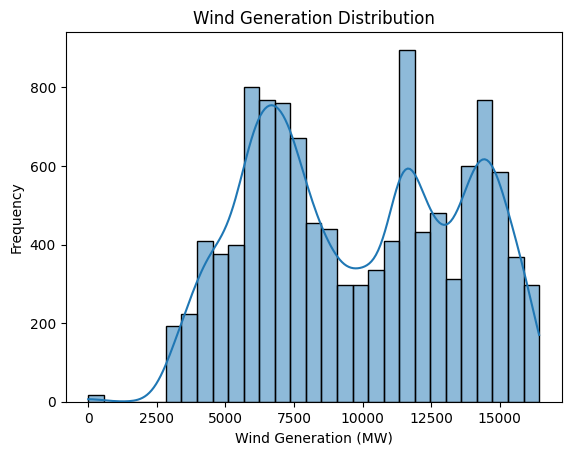

In [15]:
sns.histplot(df["actual"], kde=True)
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Frequency")
plt.title("Wind Generation Distribution")
plt.show()

The histogram shows that wind generation is generally >= 2600 MW.

Percentiles help in this case. If we know what is the wind generation that is normally exceeded most of the times, then we know the expected wind generation.


|Percentile|Meaning|
|----------|-------|
| P5       | 95% time more than X |
| P10      | 90% time more than X |
| P25      | 75% time more than X |


> lower percentile = higher conservative reliability

As the wind is highly variable, we can use p10 as the reliable contribution to electricity demand.

In [17]:
p10_actual = df["actual"].quantile(0.10)
print(f"P10 Actual: {p10_actual:.2f} MW")

P10 Actual: 5050.00 MW


In [18]:
p20_actual = df["actual"].quantile(0.20)
print(f"P20 Actual: {p20_actual:.2f} MW")

P20 Actual: 6143.00 MW


**Wind generation exceeds ~5000 MW in 90% of observations, therefore around 5000-6000 MW can be considered a reliable contribution to electricity demand.**